# Exercise 4: NumPy Array Operations

In [14]:
import numpy as np

Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

In [15]:
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


 Task 2: Normalize a random array

Normalize each column to have mean=0 and std=1

In [ ]:
np.random.seed(42)

random_data = np.random.randn(100, 3)

normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("The Column for the Means:")
print(normalized_data.mean(axis=0))

print("\nThe Column for the Standard Deviations:")
print(normalized_data.std(axis=0))

The Column for the Means:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

The Column for the Standard Deviations:
[1. 1. 1.]


 Task 3: Linear Regression using the Normal Equation

In [17]:
X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated Coefficients:")
print(theta_hat)

print("\nTrue Coefficients:")
print(true_theta)

Estimated Coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True Coefficients:
[ 2.5 -1.2  3.7]


# Exercise 5: Pandas Data Analysis

In [ ]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

df.head()

,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,NaN
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370


Task 1: Data Cleaning and Exploration


Display basic information about the dataset


In [ ]:
print("Dataset Information")
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None


Identify and count missing values

In [20]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64


Fill missing exam_score with the mean score for the student's major and fill missing hours_studied with the median for the student's year

In [ ]:
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)

df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

print(df.isnull().sum())

student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64


Task 2: Analysis

Calculate and display the average exam_score by major

In [ ]:
avg_score_by_major = df.groupby("major")["exam_score"].mean()

print(avg_score_by_major)

major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64


Find the major with the highest average exam_score

In [23]:
top_major = avg_score_by_major.idxmax()

print("The major with the highest average score is :", top_major)

The major with the highest average score is : CS


Calculate the correlation between hours_studied and exam_score

In [ ]:
correlation = df["hours_studied"].corr(df["exam_score"])

print("The correlation between hours studied and exam score is:", correlation)


The correlation between hours studied and exam score is: -0.05598138347292445


Create a new column 'performance' with categories: 'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

In [ ]:
df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 70, 80, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
)

df[["exam_score", "performance"]].head()

,exam_score,performance
0,68.199753,Needs Improvement
1,77.322537,Average
2,77.930725,Average
3,67.856486,Needs Improvement
4,93.657745,Excellent


Task 3: Advanced Analysis

For each major and year combination, calculate:
  - Number of students
 - Average exam score
 - Average hours studied

In [ ]:
summary = df.groupby(["major", "year"]).agg(
    {"student_id": "count", "exam_score": "mean", "hours_studied": "mean"}
)

print(summary)

              student_id  exam_score  hours_studied
major   year                                       
Biology 1             13   76.570059      12.677806
        2             12   74.899613      13.426372
        3             14   80.178476      14.486815
        4             15   70.697689      14.253944
CS      1             12   77.098194      13.039480
        2              7   76.155936      13.995784
        3              9   72.347626      15.039892
        4             18   78.119997      16.275541
Math    1             11   74.053167      19.001215
        2              9   81.226714      12.345468
        3             10   72.017537      15.175871
        4             16   73.103066      17.419175
Physics 1             13   77.828686      13.489911
        2             12   73.277734      14.616778
        3             17   73.134319      14.199901
        4             12   78.130194      15.550491


Identify top 5 students based on exam_score (handle ties appropriately)

In [ ]:
top_students = df.nlargest(5, "exam_score")

print(top_students)

     student_id    major  year  exam_score  assignments_completed  \
27         1027     Math     2  100.000000                      4   
57         1057       CS     2  100.000000                      8   
68         1068  Biology     3   98.146586                      1   
82         1082       CS     2   96.439441                      0   
132        1132       CS     4   96.330334                     10   

     hours_studied performance  
27        2.716265   Excellent  
57       11.870035   Excellent  
68       11.379991   Excellent  
82        7.378547   Excellent  
132      17.546891   Excellent  


Create a pivot table showing average exam_score by major (rows) and year (columns)

In [ ]:
pivot_table = pd.pivot_table(
    df, values="exam_score", index="major", columns="year", aggfunc="mean"
)

print(pivot_table)

year             1          2          3          4
major                                              
Biology  76.570059  74.899613  80.178476  70.697689
CS       77.098194  76.155936  72.347626  78.119997
Math     74.053167  81.226714  72.017537  73.103066
Physics  77.828686  73.277734  73.134319  78.130194


# Exercise 6: Data Visualization

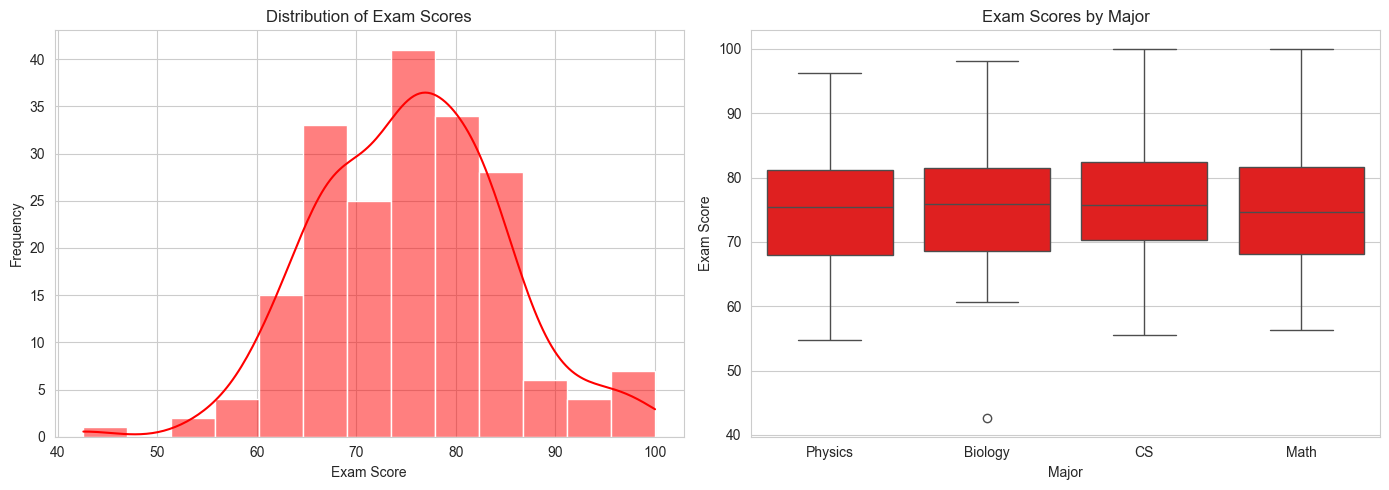

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram and the kde line
sns.histplot(data=df, x="exam_score", kde=True, ax=axes[0], color="red")

axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

#   t   he Boxplot by major
sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1], color="red")

axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

Taks 2: Relationship Visualization

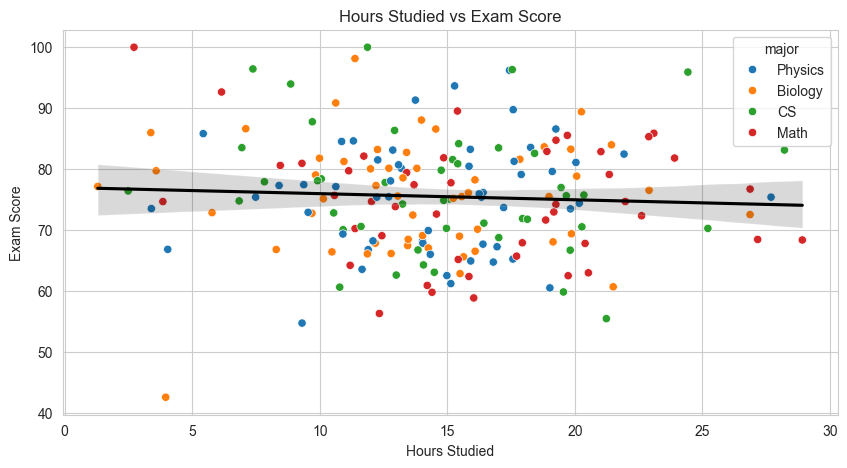

In [ ]:
plt.figure(figsize=(10, 5))
# the scatter plot with hue for major coloration
sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major")
# the regression line
sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, color="black")
# The titles and axis labels
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")

plt.show()

Task 3: Advanced Dashboard

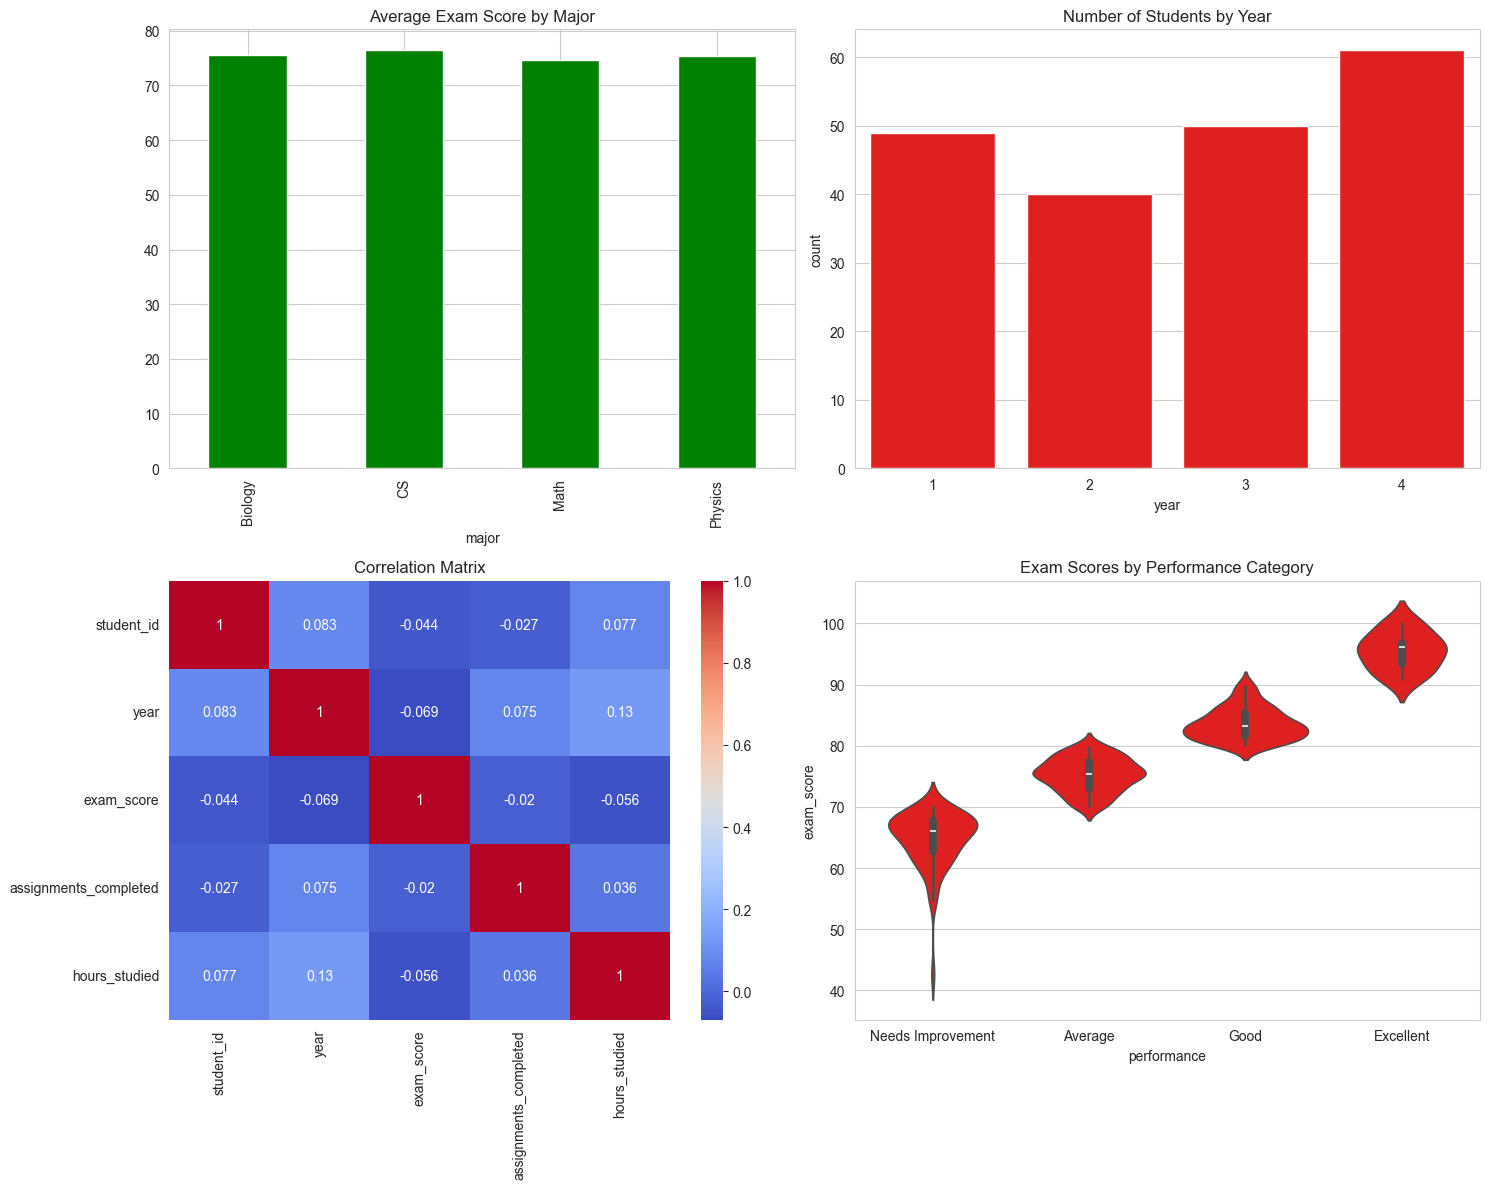

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Average score by major
avg_scores = df.groupby("major")["exam_score"].mean()

avg_scores.plot(kind="bar", color="green", ax=axes[0, 0])

axes[0, 0].set_title("Average Exam Score by Major")

# Student count by year
sns.countplot(data=df, x="year", color="red", ax=axes[0, 1])

axes[0, 1].set_title("Number of Students by Year")

# Correlation heatmap
numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", ax=axes[1, 0])

axes[1, 0].set_title("Correlation Matrix")

# Violin plot
sns.violinplot(data=df, x="performance", y="exam_score", color="red", ax=axes[1, 1])

axes[1, 1].set_title("Exam Scores by Performance Category")

plt.tight_layout()
plt.show()

# Exercise 7: Integration Challenge

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)

income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)

purchase_freq = np.random.poisson(5, n_customers)

avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

customers.head()

,age,income,purchase_frequency,avg_purchase_value
0,56,92443.123940,7,94.527456
1,69,70649.305211,2,100.932279
2,46,19612.600681,3,79.699876
3,32,40315.318543,2,130.137787
4,60,75338.222984,8,102.904845


Calculate customer lifetime value (CLV)

In [ ]:
max_frequency = customers["purchase_frequency"].max()

customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_frequency)

customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

customers.head()

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV
0,56,92443.123940,7,94.527456,0.416667,937.397271
1,69,70649.305211,2,100.932279,0.833333,370.085023
2,46,19612.600681,3,79.699876,0.750000,418.424348
3,32,40315.318543,2,130.137787,0.833333,477.171887
4,60,75338.222984,8,102.904845,0.333333,1097.651683


Create age groups: 18-25, 26-35, 36-50, 51-70

In [ ]:
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
    include_lowest=True,
)

customers[["age", "age_group"]].head()

,age,age_group
0,56,51-70
1,69,51-70
2,46,36-50
3,32,26-35
4,60,51-70


TODO: For each age group, calculate:
   - Number of customers
  - Average income
  - Average CLV
  - Total CLV

In [ ]:
age_summary = customers.groupby("age_group").agg(
    {"age": "count", "income": "mean", "CLV": ["mean", "sum"]}
)

print(age_summary)

            age        income         CLV               
          count          mean        mean            sum
age_group                                               
18-25        81  50634.018330  718.371170   58188.064760
26-35        73  48747.148046  747.738562   54584.915035
36-50       160  48516.895668  732.796612  117247.457917
51-70       186  50713.163384  762.693498  141860.990683


Identify top 10% of customers by CLV

In [ ]:
clv_threshold = customers["CLV"].quantile(0.90)

top_customers = customers[customers["CLV"] >= clv_threshold]

print(f"Top 10% customers: {len(top_customers)}")

top_customers.head()

Top 10% customers: 50


,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
6,38,58876.388563,10,110.331527,0.166667,1287.201143,36-50
9,40,48809.492879,10,110.228581,0.166667,1286.000108,36-50
19,41,21282.756976,8,119.651218,0.333333,1276.279663,36-50
24,38,53981.193911,8,120.320786,0.333333,1283.421714,36-50
57,64,45956.146951,7,135.470585,0.416667,1343.416638,51-70


Create visualizations

1. Scatter plot of income vs CLV (color by age group)

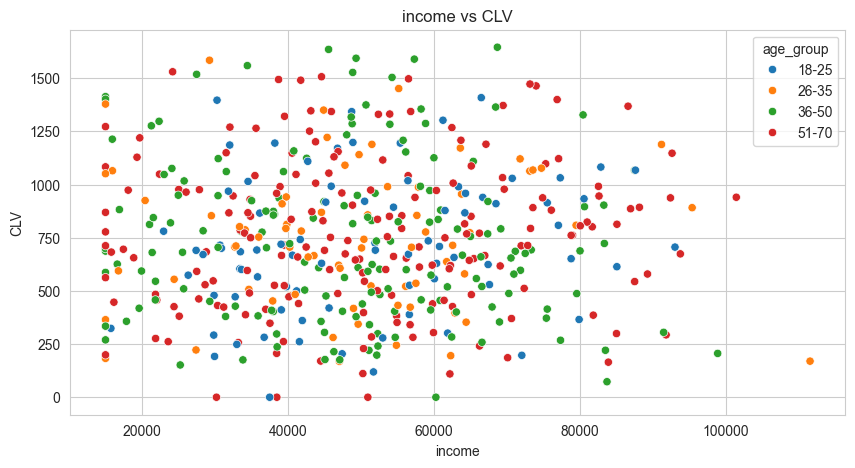

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=customers, x="income", y="CLV", hue="age_group")


plt.xlabel("income")
plt.ylabel("CLV")
plt.title("income vs CLV")
plt.show()

2. Bar chart of average CLV by age group

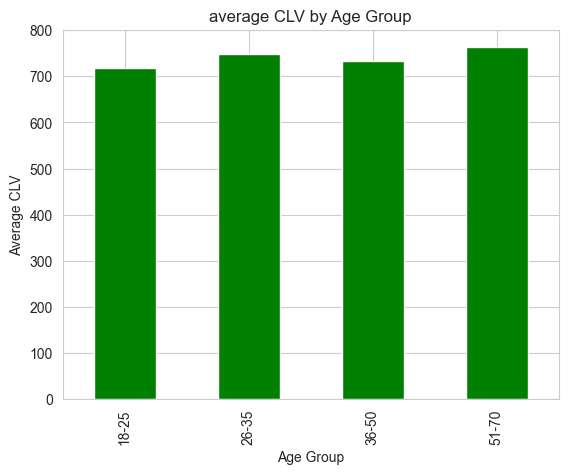

In [ ]:
avg_clv = customers.groupby("age_group")["CLV"].mean()
avg_clv.plot(
    kind="bar",
    color="green",
)
plt.title("average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.show()

3. Correlation heatmap

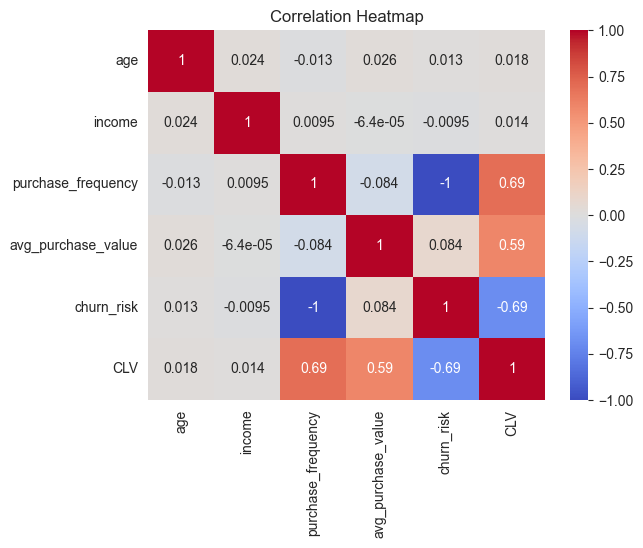

In [43]:
numeric_df = customers.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot = True,
    cmap = 'coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

Write a brief analysis paragraph (as a markdown cell)
summarizing key findings and recommendations

The scatter plt shows that income does not have much influence on customer life value(CLV). The bar chat indicates that the age group 51-70 has the highest CLV, while 18-25 age group has the lowest.Also, from the heatmap, purchase frequency has the strongest positive relationship with CLV, while the chrn risk has a strong negative relationship. This suggests that customers who buy more ofter are more valuable to the company.
Baes on the resules of this analysis, the company should focus on retening and encouraging customers to purchase frequently to improve customer life value.